# Importação do .csv tratado

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

df = pd.read_csv('../../db/clean/bilheteria-distribuidoras.csv')
df_list = pd.read_csv('../../db/clean/listagem-distribuidoras.csv')
df_salas = pd.read_csv('../../db/clean/salas-de-exibicao.csv')
df_censo = pd.read_csv('../../db/censo_2022_populacao.csv')
df.head()

,data_exibicao,titulo,cpb_roe,pais_obra,registro_sala,publico,uf_sala_complexo,razao_social_distribuidora,capacidade_sala
0,2014-01-01,UM TOQUE DE PECADO,E1600132700000,CHINA,5000866,16,RS,SM DISTRIBUIDORA DE FILMES LTDA,98
1,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,5000674,14,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,221
2,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,5000795,60,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,119
3,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,5003834,0,SC,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,201
4,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,5003845,0,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA,225


In [2]:
df['razao_social_distribuidora'].value_counts()

razao_social_distribuidora
WARNER BROS. (SOUTH) INC.                                 3966400
THE WALT DISNEY COMPANY (BRASIL) LTDA.                    3014983
COLUMBIA TRISTAR FILMES DO BRASIL LTDA                    2187979
SM DISTRIBUIDORA DE FILMES LTDA                           1643875
PARAMOUNT PICTURES BRASIL DISTRIBUIDORA DE FILMES LTDA    1208863
                                                           ...   
MOSQUITO VIDEO E DESIGN LTDA                                    1
44 BICO LARGO COMERCIAL LTDA                                    1
SCHÜRMANN PRODUÇÕES CINEMATOGRÁFICAS LTDA                       1
KALAKUTA PRODUÇÕES ARTÍSTICAS LTDA - EPP                        1
ROBERTA GORNISKI                                                1
Name: count, Length: 328, dtype: int64

# Análise Univariada

## Ingressos vendidos entre os anos de 2014 e 2025
Análise do público atingido por obras cinematográficas entre 2014 e 2025.

In [3]:
publico = df['publico'].sum()
print(f'O público total entre 2014 e 2025 foi de {publico} pessoas')

O público total entre 2014 e 2025 foi de 812504194 pessoas


Ou seja, mais de oitoceitos milhões de ingressos de cinema foram vendidos durante esse período de tempo.

## Média de público

In [4]:
media_publico = df['publico'].mean()
print(f'A média de público entre 2014 e 2025 foi de {int(media_publico)} pessoas')

A média de público entre 2014 e 2025 foi de 49 pessoas


## Média de capacidade das salas

In [5]:
media_capacidade = df['capacidade_sala'].mean()
print(f'A média de capacidade das salas de cinema é de {int(media_capacidade)} pessoas')

A média de capacidade das salas de cinema é de 191 pessoas


## País com mais sessões em salas de cinema

In [6]:
moda = df['pais_obra'].mode()[0]
print(f'O país com mais sessões é {moda.capitalize()}')

O país com mais sessões é Estados unidos


Vemos através desta análise que os Estados Unidos detém a maior quantidade de sessões em salas de cinema. Poderemos futuramente aferir o quão notável é esta diferença, principalmente em relação a filmes brasileiros.

## Filme com mais sessões

In [7]:
moda = df['titulo'].mode()[0]
print(f'O filme com mais sessões é {moda.capitalize()}')

O filme com mais sessões é Avatar: o caminho da água


Esta análise conclui que o filme com mais sessões registradas no Brasil entre 2014 e 2025 é "Avatar: O Caminho da Água". Segundo o portal Box Office Mojo, trata-se do filme com a sétima maior bilheteria da história do cinema, arrecadando quase 700 milhões de dólares.

https://www.boxofficemojo.com/chart/top_lifetime_gross/

## Estado com mais sessões

In [8]:
moda = df['uf_sala_complexo'].mode()[0]
print(f'O estado com mais sessões é {moda.upper()}')

O estado com mais sessões é SP


A análise indica que o estado com mais sessões de cinema registradas é São Paulo. Análises futuras podem nos indicar melhor a proporçao de salas e sessões de cinema proporcionalmente para cada estado, levando em conta as suas populações.

# Análise Bivariada

## Análise de filmes distribuidos

In [9]:
df['tipo_filme'] = df['cpb_roe'].apply(lambda x: 'Estrangeiro' if str(x).startswith('E') else 'Brasileiro')

In [10]:
df['data_exibicao'] = pd.to_datetime(df['data_exibicao'])
df['ano'] = df['data_exibicao'].dt.year

### Salas de cinema para filmes brasileiros e estrangeiros

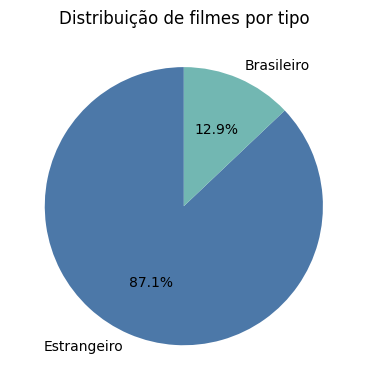

In [11]:
counts = df['tipo_filme'].value_counts()

counts.plot.pie(
  figsize=(4,4),
  autopct='%1.1f%%',
  colors=['#4C78A8', '#72B7B2'],
  startangle=90,
  ylabel='',
  labels=counts.index,
  title='Distribuição de filmes por tipo'
)

plt.tight_layout()
plt.show()

Nitidamente, percebemos que há uma grande discrepância entre a distribuição de filmes estrangeiros e nacionais, com uma grande predominância do cinema estrangeiro, que domina quase 90% das salas.

### Filmes únicos distribuidos por país

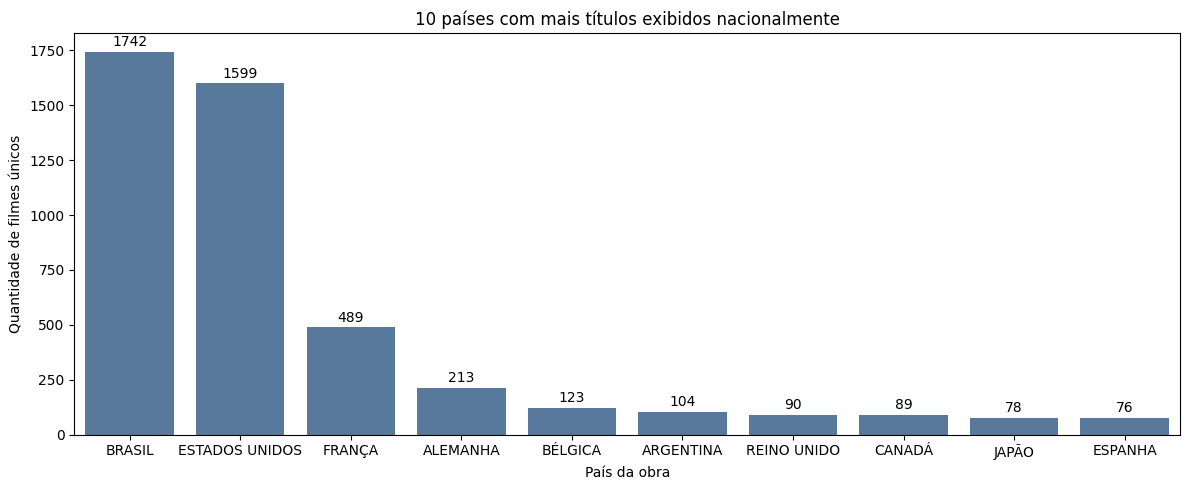

In [12]:
df_uni = (
    df.drop_duplicates(subset=['pais_obra', 'cpb_roe'])
)

# Top 10 países por quantidade
vc = df_uni['pais_obra'].value_counts().head(10)
top = vc.index

fig = plt.subplots(figsize=(12,5))
ax = sns.countplot(
    data=df_uni[df_uni['pais_obra'].isin(top)],
    x='pais_obra',
    order=top,
    color="#4C78A8",
)
ax.set(
  xlabel='País da obra',
  ylabel='Quantidade de filmes únicos',
  title='10 países com mais títulos exibidos nacionalmente'
)
ax.bar_label(ax.containers[0], labels=[f"{int(c)}" for c in vc.values], padding=2)

plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

Constatamos através do gráfico acima que a exibição de filmes nos cinemas nacionais está concentrado principalmente em filmes brasileiros e estadunidenses.
Percebemos um certo choque de informações ao comparar esse gráfico e o gráfico anterior, que mostra uma clara diferença favorecendo títulos do cinema estrangeiro em detrimento de obras nacionais. Uma hipótese imediata para isso é que, apesar de menos títulos, cada título estrangeiro possui, em média, mais salas de cinema para exibição do que os nacionais. Poderemos confirmar ou descartar essa hipótese baseando-se em outras análises com a ajuda de gráficos, coisa que será feita mais adiante.

### Filmes estrangeiros x brasileiros por ano

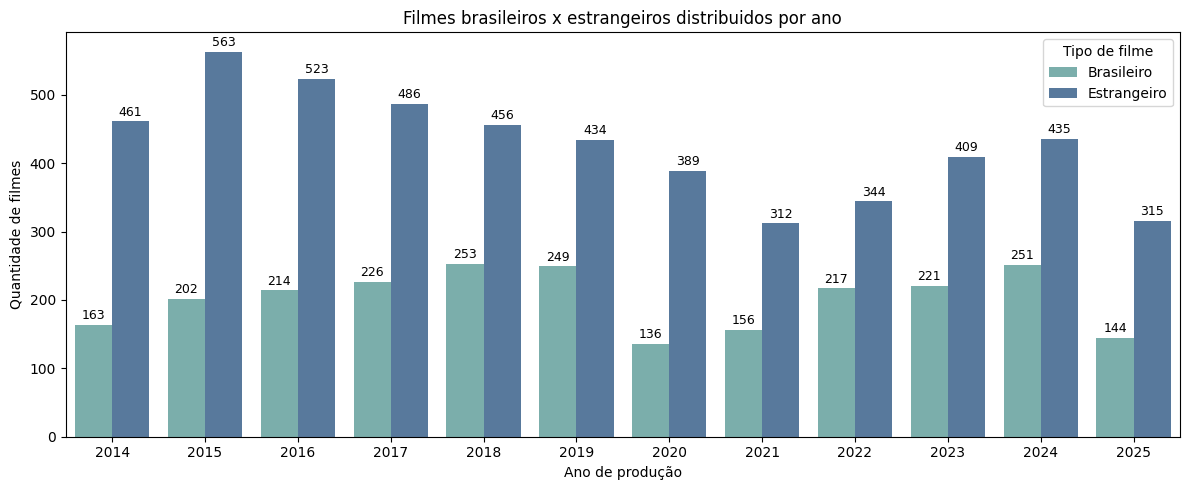

In [13]:
reg_unicos = (
    df.drop_duplicates(subset=['ano', 'cpb_roe'])
)

contagem = (
    reg_unicos.groupby(['ano', 'tipo_filme'])
             .size()
             .reset_index(name='count')
)

anos_ord = sorted(contagem['ano'].unique())

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=contagem,
    x='ano',
    y='count',
    hue='tipo_filme',
    order=anos_ord,
    palette=['#72B7B2','#4C78A8']
)

ax.set_xlabel('Ano de produção')
ax.set_ylabel('Quantidade de filmes')
ax.set_title('Filmes brasileiros x estrangeiros distribuidos por ano')

# Rótulos com contagem absoluta
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.tight_layout()
plt.show()

### Comparação relativa entre número de filmes e de salas para filmes nacionais e estrangeiros

### Público absoluto em filmes brasileiros e em filmes estrangeiros

In [14]:
publico_total = df.groupby('tipo_filme')['publico'].sum()
print(publico_total)

tipo_filme
Brasileiro      81579792
Estrangeiro    730924402
Name: publico, dtype: int64


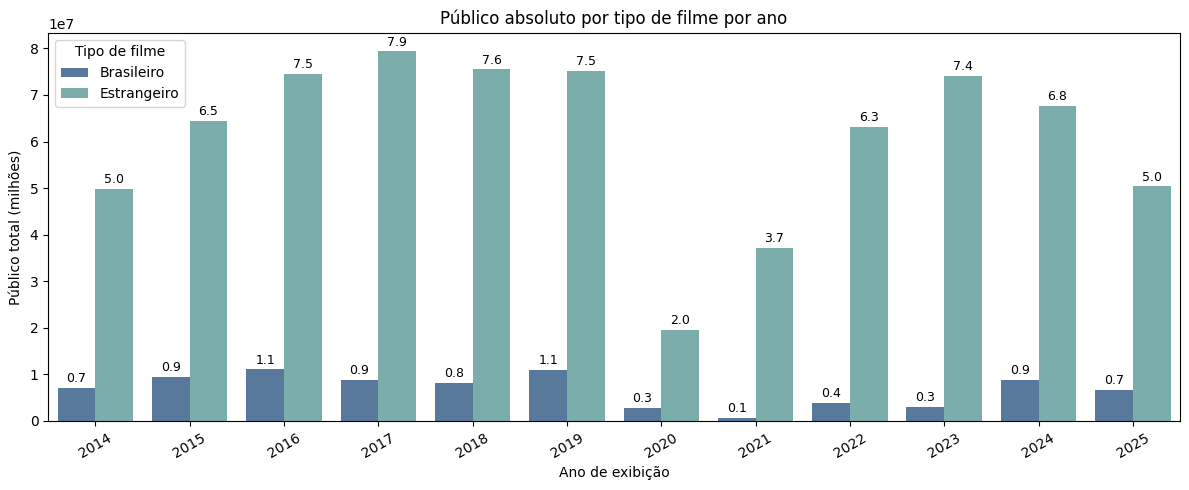

In [15]:
publico_por_ano = df.groupby(['ano', 'tipo_filme'])['publico'].sum().reset_index()

plt.figure(figsize=(12,5))
ax = sns.barplot(data=publico_por_ano, x='ano', y='publico', hue='tipo_filme', palette=['#4C78A8', '#72B7B2'])

ax.set_xlabel('Ano de exibição')
ax.set_ylabel('Público total (milhões)')
ax.set_title('Público absoluto por tipo de filme por ano')

# Rótulos no topo das barras em milhares
for container in ax.containers:
    ax.bar_label(container, labels=[f'{round(v.get_height()/10000000, 1)}' for v in container], padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Maiores distribuidoras por volume de filmes distribuidos

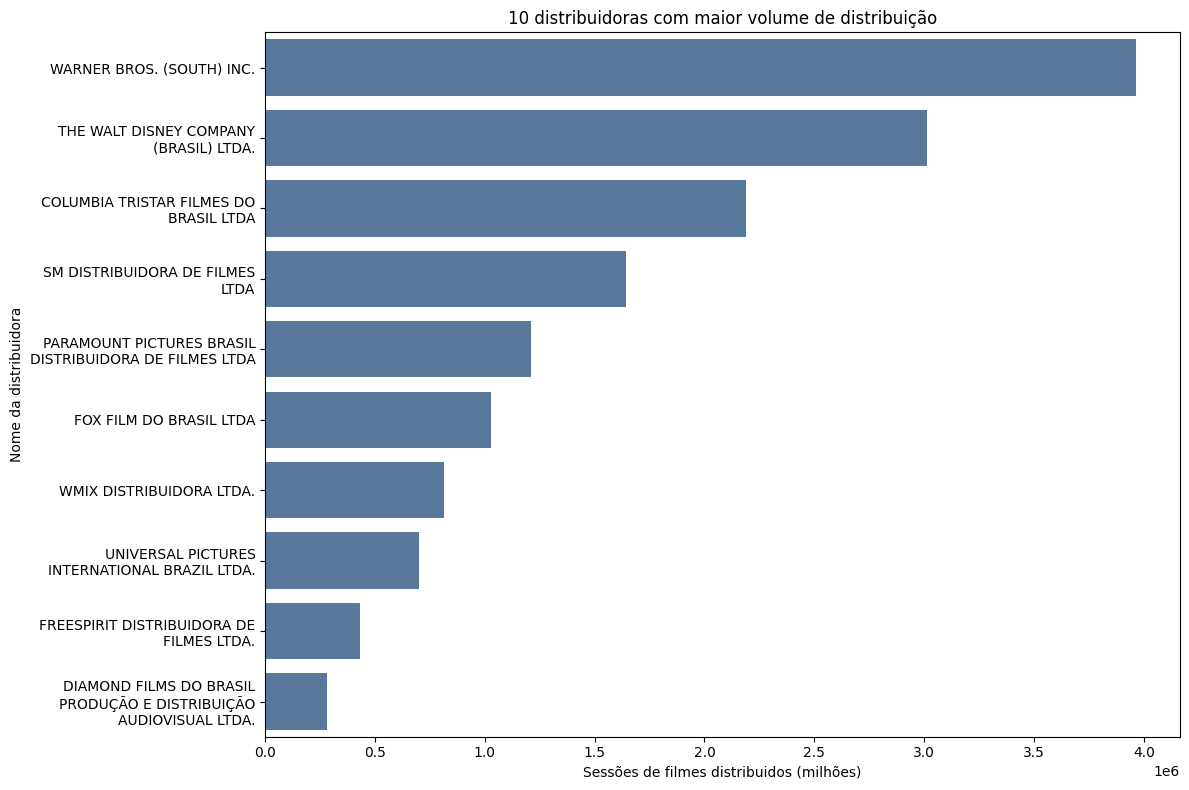

In [16]:
vc = df['razao_social_distribuidora'].value_counts().head(10)
top = vc.index

plt.figure(figsize=(12,8))
ax = sns.countplot(
    data=df[df['razao_social_distribuidora'].isin(top)],
    y='razao_social_distribuidora',
    order=top,
    color="#4C78A8"
)

# Aplica text wrap nas labels do eixo Y
labels = [label.get_text() for label in ax.get_yticklabels()]
wrapped_labels = ['\n'.join(textwrap.wrap(label, width=30)) for label in labels]
ax.set_yticks(ax.get_yticks())  # Define os ticks antes de mudar as labels
ax.set_yticklabels(wrapped_labels)

ax.set_ylabel('Nome da distribuidora')
ax.set_xlabel('Sessões de filmes distribuidos (milhões)')
ax.set_title('10 distribuidoras com maior volume de distribuição')

plt.tight_layout()
plt.show()

### Interesse por distribuição de obras nacionais

/tmp/ipykernel_5815/1830119697.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped_labels)


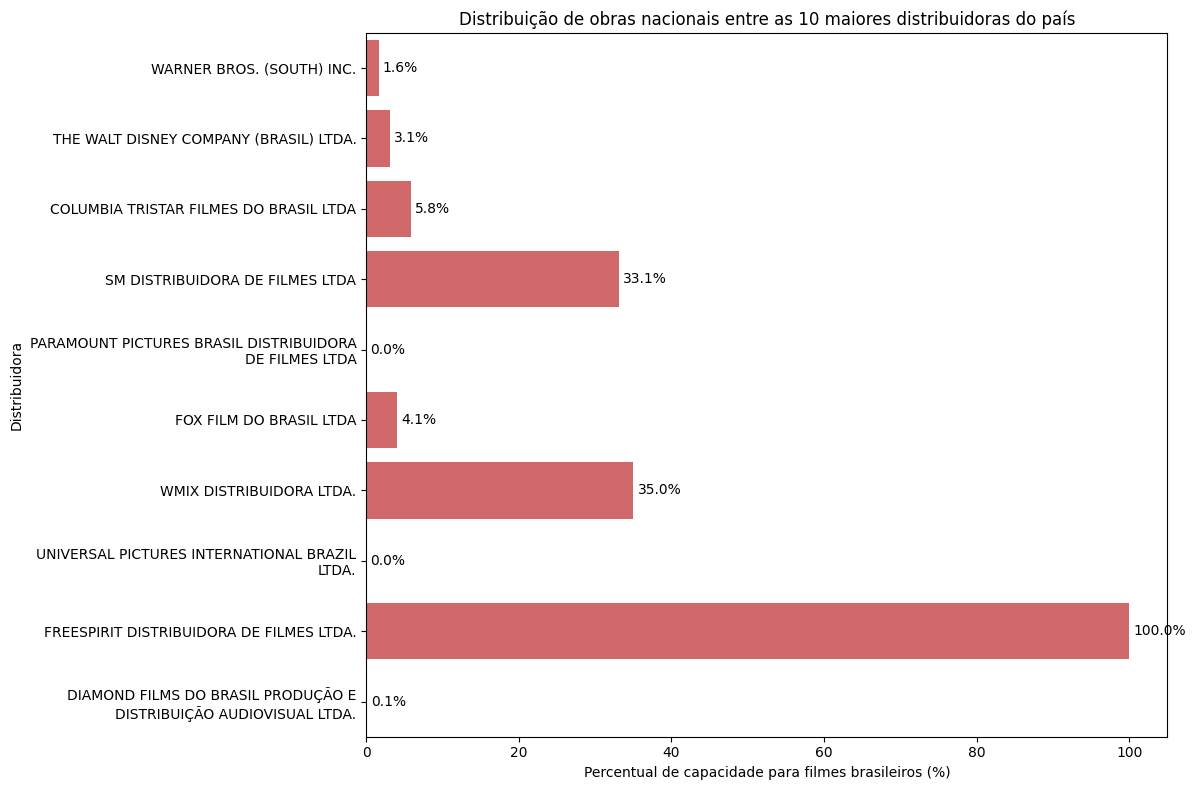

In [17]:
df_razao = pd.DataFrame({
    'cap_nacional': df[df['tipo_filme'] == 'Brasileiro'].groupby('razao_social_distribuidora')['capacidade_sala'].sum(),
    'cap_total': df.groupby('razao_social_distribuidora')['capacidade_sala'].sum()
})

df_razao['razao_pct'] = (df_razao['cap_nacional'] / df_razao['cap_total'] * 100).fillna(0)

# Top 10 distribuidoras com maior razão
top_10_razao = df_razao.nlargest(10, 'cap_total')

# Cria o gráfico
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_10_razao.reset_index(),
            y='razao_social_distribuidora',
            x='razao_pct',
            color='#E15759', ax=ax)

# Aplica text wrap nas labels do eixo Y
labels = [label.get_text() for label in ax.get_yticklabels()]
wrapped_labels = ['\n'.join(textwrap.wrap(label, width=40)) for label in labels]
ax.set_yticklabels(wrapped_labels)

ax.set(xlabel='Percentual de capacidade para filmes brasileiros (%)',
       ylabel='Distribuidora',
       title='Distribuição de obras nacionais entre as 10 maiores distribuidoras do país')

# Adiciona os valores nas barras
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in top_10_razao['razao_pct']], padding=3)

plt.tight_layout()
plt.show()

In [18]:
df_salas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6252 entries, 0 to 6251
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nome_sala      6252 non-null   object
 1   registro_sala  6252 non-null   int64 
 2   assentos_sala  6252 non-null   int64 
 3   uf_complexo    6252 non-null   object
 4   situacao_sala  6252 non-null   object
dtypes: int64(2), object(3)
memory usage: 244.3+ KB


Para a criação do gráfico acima, o interesse pela distribuição de obras nacionais foi medida através da razão entre a quantidade de assentos de salas de cinema reservados a obras nacionais e o total de assentos. É possível notar que, dentre as 10 maiores distribuidoras de filmes em atividade no Brasil, 7 delas possuem percentual abaixo de 10%. A única distribuidora voltada exclusivamente para distribuição de obras nacionais que aparece na lista é a Freespirit.

### Relação entre quantidade de assentos e público de sessões de filmes nacionais e estrangeiros

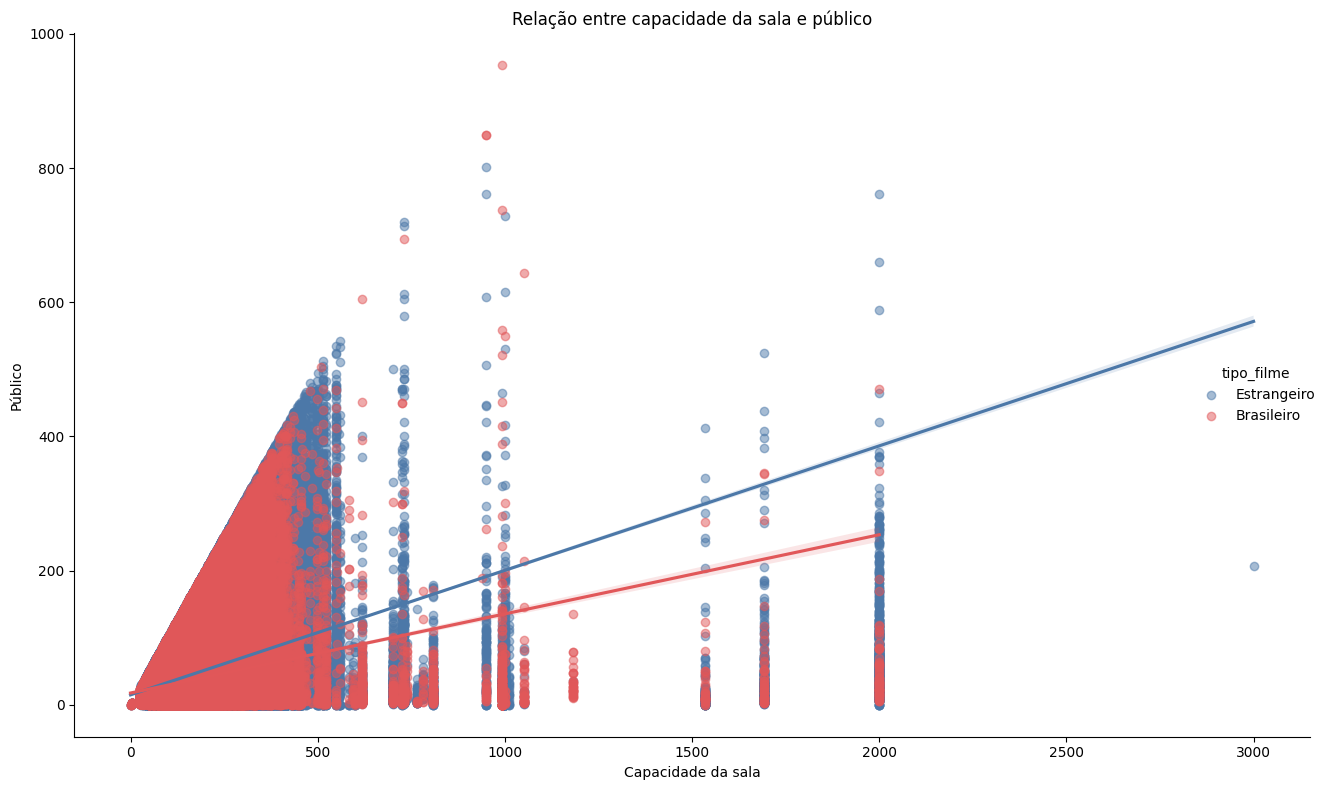

In [19]:
# data = df # Utiliza todos os registros
data = df.sample(frac=0.10) # Utiliza uma amostra aleatória de 10% dos dados

sns.lmplot(data=data, x='capacidade_sala', y='publico', hue='tipo_filme',
           palette={'Estrangeiro': '#4C78A8', 'Brasileiro': '#E15759'},
           height=8, aspect=1.5, scatter_kws={'alpha': 0.5})

plt.xlabel('Capacidade da sala')
plt.ylabel('Público')
plt.title('Relação entre capacidade da sala e público')
plt.tight_layout()
plt.show()

O gráfico acima mostra que, em média, filmes estrangeiros tendem a ter um público maior em salas de grande capacidade em comparação com os filmes brasileiros. Embora a relação entre capacidade e público seja positiva para ambos, é visível que o aumento de público seguindo aumento da quantidade de assentos é visivelmente mais acentuado pra filmes estrangeiros.

### Relação entre público total e público em obras nacionais

In [20]:
df_list.sort_values(by='publico', ascending=False)

,ano_exibicao,distribuidora,origem_empresa,publico,publico_br,renda,renda_br,titulos_exibidos,titulos_exibidos_br,titulos_lancados,titulos_lancados_br
871,2019,Disney,Distribuição Internacional,75770402,432182,1.249378e+09,6813529.00,38,3,16,1
772,2018,Disney,Distribuição Internacional,39619366,0,6.292771e+08,0.00,26,0,10,0
550,2016,Disney,Distribuição Internacional,39058991,153234,5.720642e+08,1935131.00,32,1,15,1
624,2016,Warner,Distribuição Internacional,36387021,674447,5.366155e+08,9220289.00,29,2,20,2
505,2015,Universal,Distribuição Internacional,35954980,439446,4.985765e+08,5159604.63,28,2,20,1
...,...,...,...,...,...,...,...,...,...,...,...
1096,2022,Espaço Filmes,Distribuição Nacional,4,4,6.000000e+01,60.00,1,1,0,0
566,2016,Film Connection/Imovision,Distribuição Nacional,2,2,2.340000e+01,23.40,1,1,0,0
1157,2022,Walper Ruas Produções,Distribuição Nacional,2,2,4.800000e+01,48.00,1,1,0,0
814,2018,Modo Operante Produções,Distribuição Nacional,0,0,0.000000e+00,0.00,1,1,0,0


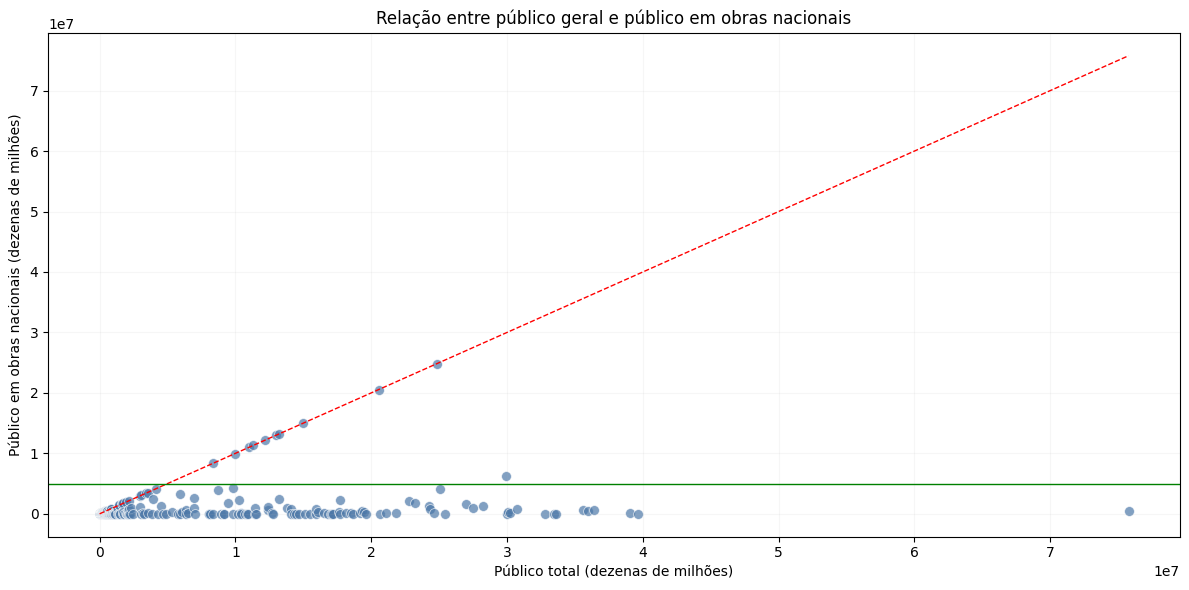

In [21]:
df_list_sorted = df_list.sort_values('publico').reset_index(drop=True)

plt.figure(figsize=(12,6))
ax = sns.scatterplot(data=df_list_sorted, x='publico', y='publico_br', alpha=0.7, s=50, color='#4C78A8')

# Linha vermelha pontilhada onde x = y
min_val = min(df_list_sorted['publico'].min(), df_list_sorted['publico_br'].min())
max_val = max(df_list_sorted['publico'].max(), df_list_sorted['publico_br'].max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

# Linha verde horizontal
ax.axhline(y=5000000, color='green', linestyle='-', linewidth=1)

plt.xlabel('Público total (dezenas de milhões)')
plt.ylabel('Público em obras nacionais (dezenas de milhões)')
plt.title('Relação entre público geral e público em obras nacionais')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

O gráfico acima mostra uma relação entre público total obtido por distribuidoras e público obtido exclusivamente através da divulgação de obras nacionais. Os pontos que se encontram em cima da linha vemelha pontilhada representam as distribuidoras voltadas exclusivamente apenas para a distribuição de obras nacionais. É notável que, excluindo essas empresas, a distribuição de filmes brasileiros quase nunca excede o público de 5 milhões (linha verde), independentemente do crescimento do público total. Este é um indicativo de que a distribuição de obras nacionais ainda é deficitária em grandes empresas do ramo audiovisual.

In [22]:
df.sort_values(by='capacidade_sala', ascending=False)

,data_exibicao,titulo,cpb_roe,pais_obra,registro_sala,publico,uf_sala_complexo,razao_social_distribuidora,capacidade_sala,tipo_filme,ano
8551116,2020-08-14,A FREIRA,E1800306100000,ESTADOS UNIDOS,5006622,15,SP,WARNER BROS. (SOUTH) INC.,3000,Estrangeiro,2020
8551123,2020-08-15,NASCE UMA ESTRELA,E1800303500000,ESTADOS UNIDOS,5006622,35,SP,WARNER BROS. (SOUTH) INC.,3000,Estrangeiro,2020
8550782,2020-08-08,A CABANA,E1700059700000,ESTADOS UNIDOS,5006622,207,SP,SM DISTRIBUIDORA DE FILMES LTDA,3000,Estrangeiro,2020
8551628,2020-08-22,AVES DE RAPINA (ARLEQUINA E SUA EMANCIPAÇÃO FA...,E1900628800000,ESTADOS UNIDOS,5006622,47,SP,WARNER BROS. (SOUTH) INC.,3000,Estrangeiro,2020
7404981,2019-06-30,PETS: A VIDA SECRETA DOS BICHOS 2,E1900162100000,ESTADOS UNIDOS,5002102,230,DF,UNIVERSAL PICTURES INTERNATIONAL BRAZIL LTDA.,2000,Estrangeiro,2019
...,...,...,...,...,...,...,...,...,...,...,...
747648,2014-10-15,JULIO SUMIU,B1402115000000,BRASIL,5000897,0,SP,WMIX DISTRIBUIDORA LTDA.,0,Brasileiro,2014
1081,2014-01-01,FROZEN: UMA AVENTURA CONGELANTE,E1500922200000,ESTADOS UNIDOS,5001535,0,SP,THE WALT DISNEY COMPANY (BRASIL) LTDA.,0,Estrangeiro,2014
535856,2014-07-29,A CULPA É DAS ESTRELAS,E1402308800000,ESTADOS UNIDOS,5001535,0,SP,FOX FILM DO BRASIL LTDA,0,Estrangeiro,2014
145023,2014-02-25,UMA AVENTURA LEGO,E1500178000000,ESTADOS UNIDOS,5001535,0,SP,WARNER BROS. (SOUTH) INC.,0,Estrangeiro,2014


In [23]:
df_salas['situacao_sala'].value_counts()

situacao_sala
EM FUNCIONAMENTO           3684
FECHADO                    2512
FECHADO TEMPORARIAMENTE      56
Name: count, dtype: int64

### Análise de títulos específicos

In [35]:
df['titulo'].value_counts()

titulo
AVATAR: O CAMINHO DA ÁGUA            100885
HOMEM-ARANHA: SEM VOLTA PARA CASA     74800
MINIONS 2: A ORIGEM DE GRU            74620
AINDA ESTOU AQUI                      73704
MULHER-MARAVILHA 1984                 72806
                                      ...  
CONTATOS DE 4º GRAU                       1
ENTREVISTA COM O VAMPIRO                  1
CORAÇÃO ARDENTE                           1
XICO STOCKINGER                           1
IRMÃS JAMAIS                              1
Name: count, Length: 5216, dtype: int64

A tabela acima mostra que o pódio de filmes com mais sessões é dominado por obras estadunidenses. Entre os 50 filmes com mais sessões, apenas dois são brasileiros: "Ainda Estou Aqui" e "Minha Mãe É Uma Peça 3". Trata-se de mais um indício da dominância do cinema americano nas salas de cinema do Brasil.

### Distribuição de público por estado

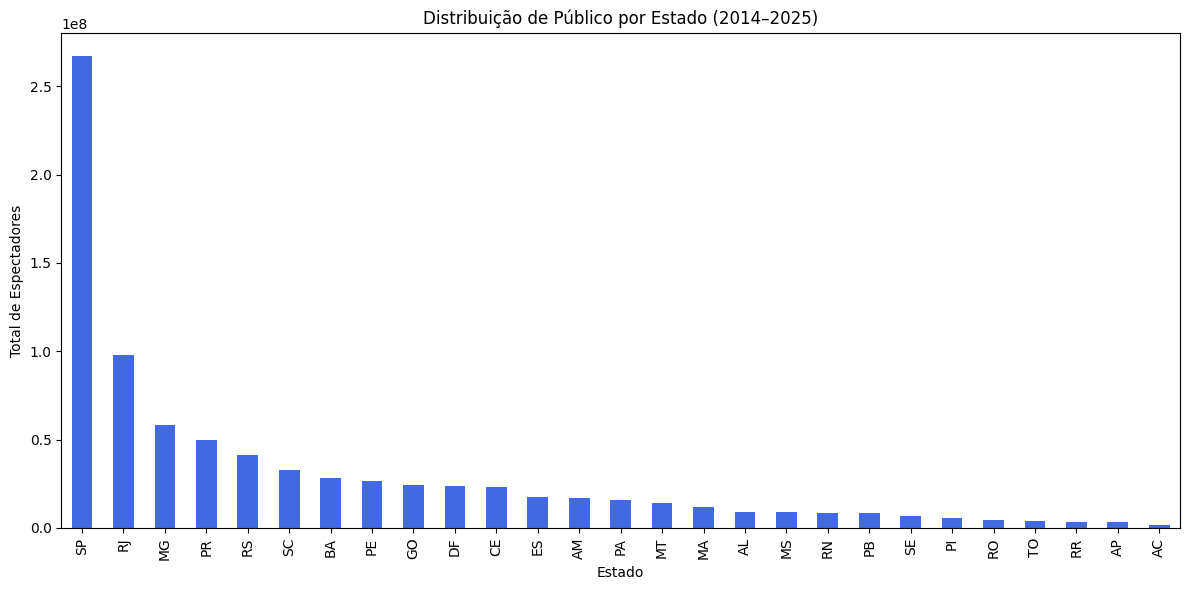

In [25]:
plt.figure(figsize=(12,6))
df.groupby('uf_sala_complexo')['publico'].sum().sort_values(ascending=False).plot(kind='bar', color='royalblue')
plt.title('Distribuição de Público por Estado (2014–2025)')
plt.xlabel('Estado')
plt.ylabel('Total de Espectadores')
plt.tight_layout()
plt.show()


### Evolução anual do público (2014–2025)

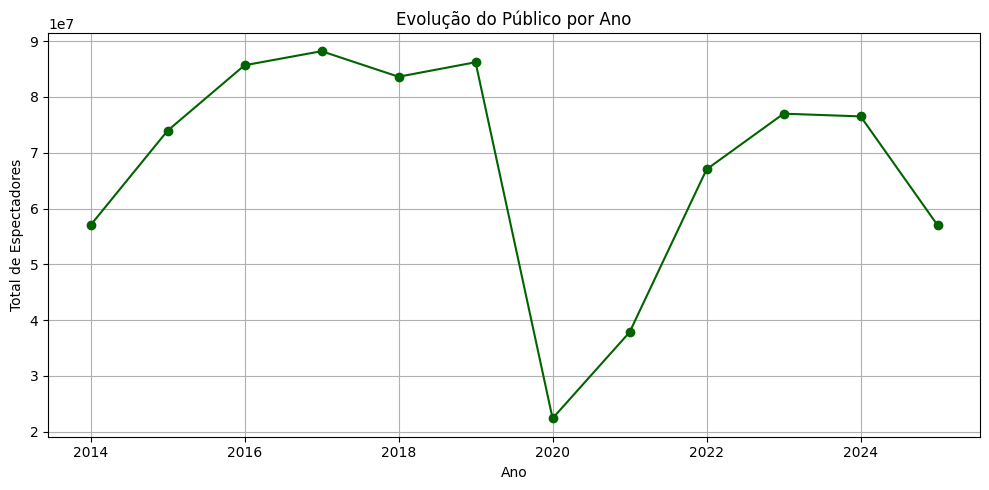

In [26]:
df['ano_exibicao'] = pd.to_datetime(df['data_exibicao'], errors='coerce').dt.year
publico_por_ano = df.groupby('ano_exibicao')['publico'].sum()

plt.figure(figsize=(10,5))
publico_por_ano.plot(marker='o', color='darkgreen')
plt.title('Evolução do Público por Ano')
plt.xlabel('Ano')
plt.ylabel('Total de Espectadores')
plt.grid(True)
plt.tight_layout()
plt.show()


### Top 10 distribuidoras por público

/tmp/ipykernel_5815/1052417343.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_distribuidoras.values, y=top_distribuidoras.index, palette='mako')


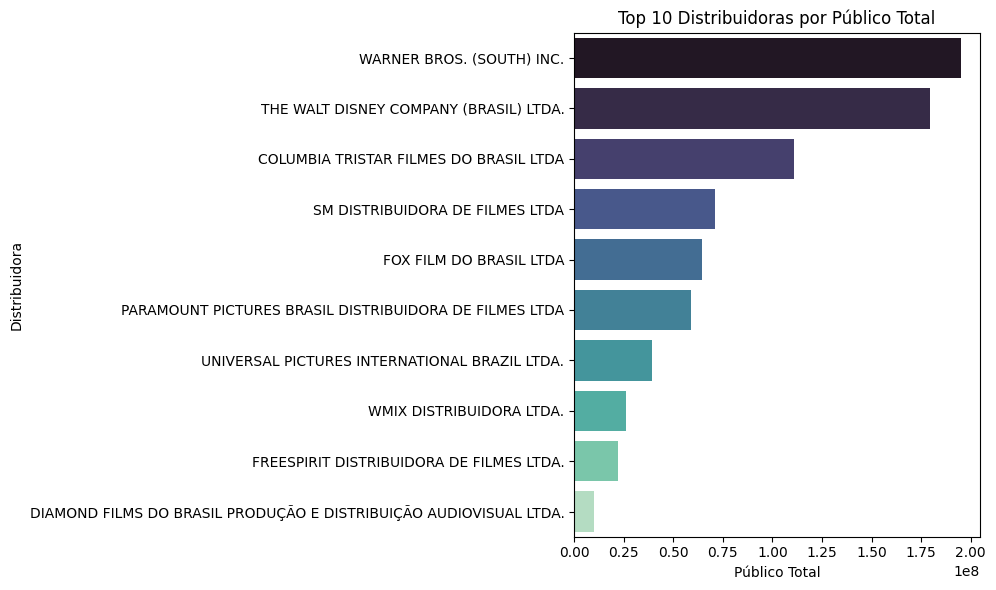

In [27]:
top_distribuidoras = df.groupby('razao_social_distribuidora')['publico'].sum().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_distribuidoras.values, y=top_distribuidoras.index, palette='mako')
plt.title('Top 10 Distribuidoras por Público Total')
plt.xlabel('Público Total')
plt.ylabel('Distribuidora')
plt.tight_layout()
plt.show()


### Proporção de público: filmes nacionais vs estrangeiros

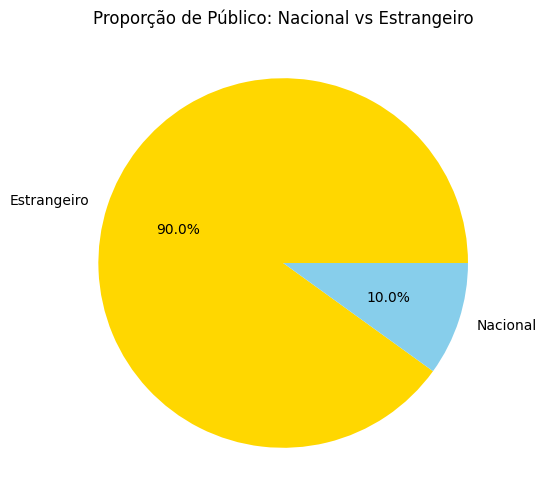

In [28]:
df['origem'] = df['pais_obra'].apply(lambda x: 'Nacional' if 'BRASIL' in str(x).upper() else 'Estrangeiro')
origem_counts = df.groupby('origem')['publico'].sum()

plt.figure(figsize=(6,6))
origem_counts.plot(kind='pie', autopct='%1.1f%%', colors=['gold', 'skyblue'])
plt.title('Proporção de Público: Nacional vs Estrangeiro')
plt.ylabel('')
plt.show()


### Relação entre número de salas e público por estado

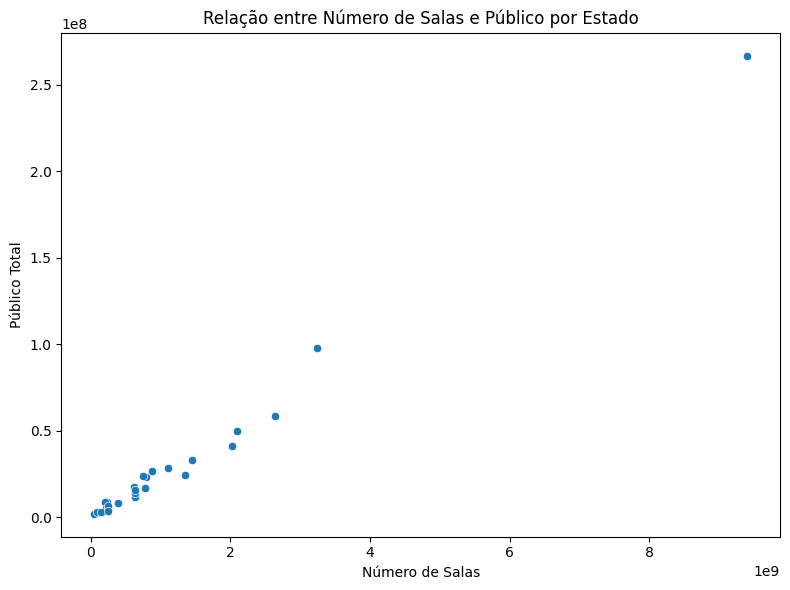

In [29]:
salas_estado = df_salas.groupby('uf_complexo')['registro_sala'].sum()
publico_estado = df.groupby('uf_sala_complexo')['publico'].sum()
comparativo = pd.concat([salas_estado, publico_estado], axis=1).dropna()
comparativo.columns = ['Salas', 'Público']

plt.figure(figsize=(8,6))
sns.scatterplot(x='Salas', y='Público', data=comparativo)
plt.title('Relação entre Número de Salas e Público por Estado')
plt.xlabel('Número de Salas')
plt.ylabel('Público Total')
plt.tight_layout()
plt.show()


### Média de público por distribuidora

/tmp/ipykernel_5815/2164345783.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_publico_distrib.values, y=media_publico_distrib.index, palette='viridis')


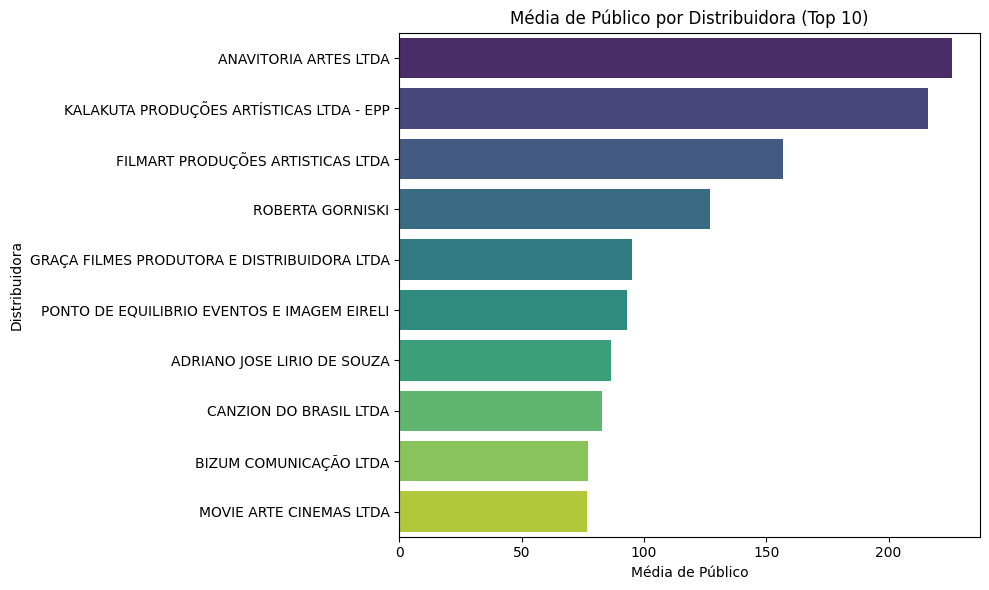

In [30]:
media_publico_distrib = df.groupby('razao_social_distribuidora')['publico'].mean().nlargest(10)

plt.figure(figsize=(10,6))
sns.barplot(x=media_publico_distrib.values, y=media_publico_distrib.index, palette='viridis')
plt.title('Média de Público por Distribuidora (Top 10)')
plt.xlabel('Média de Público')
plt.ylabel('Distribuidora')
plt.tight_layout()
plt.show()


### Análise sazonal: público por mês

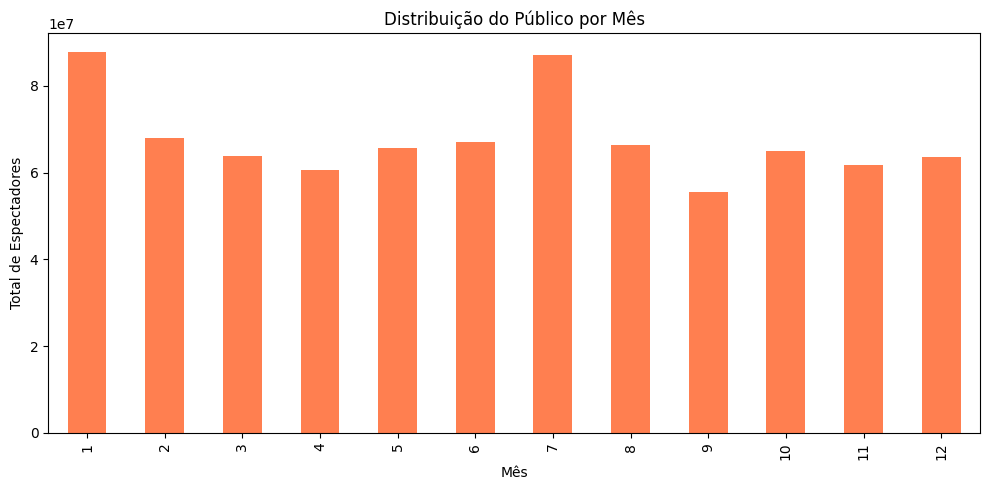

In [31]:
df['mes_exibicao'] = pd.to_datetime(df['data_exibicao'], errors='coerce').dt.month
publico_mes = df.groupby('mes_exibicao')['publico'].sum()

plt.figure(figsize=(10,5))
publico_mes.plot(kind='bar', color='coral')
plt.title('Distribuição do Público por Mês')
plt.xlabel('Mês')
plt.ylabel('Total de Espectadores')
plt.tight_layout()
plt.show()
